In [1]:
import pandas as pd
from pathlib import Path

# Yerel proje bağlantısı
PROJECT_ROOT = Path("..").resolve()
path = PROJECT_ROOT

# Gerekli çıktı klasörlerini oluştur
(path / "reports" / "figures").mkdir(parents=True, exist_ok=True)
(path / "reports" / "results").mkdir(parents=True, exist_ok=True)

# Senin kullanacağın verileri okuyalım
# KNN için ölçeklenmiş, diğerleri için ham veri lazım
X_train = pd.read_csv(path / "data" / "X_train.csv")
X_test = pd.read_csv(path / "data" / "X_test.csv")
X_train_scaled = pd.read_csv(path / "data" / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(path / "data" / "X_test_scaled.csv")
y_train = pd.read_csv(path / "data" / "y_train.csv").values.ravel()
y_test = pd.read_csv(path / "data" / "y_test.csv").values.ravel()

print("Veriler hazır")
print("Proje klasörü:", path)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Veriler hazır
Proje klasörü: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje
X_train: (10834, 16)
X_test: (2709, 16)
X_train_scaled: (10834, 16)
X_test_scaled: (2709, 16)
y_train: (10834,)
y_test: (2709,)


K-En Yakın Komşu Modeli(KNN)

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modeli tanımla (n_neighbors=5 standart bir başlangıçtır)
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Modeli ölçeklenmiş veriyle eğit
knn.fit(X_train_scaled, y_train)

# 3. Tahmin yap
y_pred_knn = knn.predict(X_test_scaled)

# 4. Sonuçları gör
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9154669619785899

Sınıflandırma Raporu:
               precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [3]:
# Sonuçları tutmak için bir liste oluşturalım (Dosyanın en başında bir kez yap)
model_results = []

# KNN sonuçlarını bu listeye ekle
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')

model_results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Weighted Precision': precision,
    'Weighted Recall': recall,
    'Weighted F1-score': f1
})

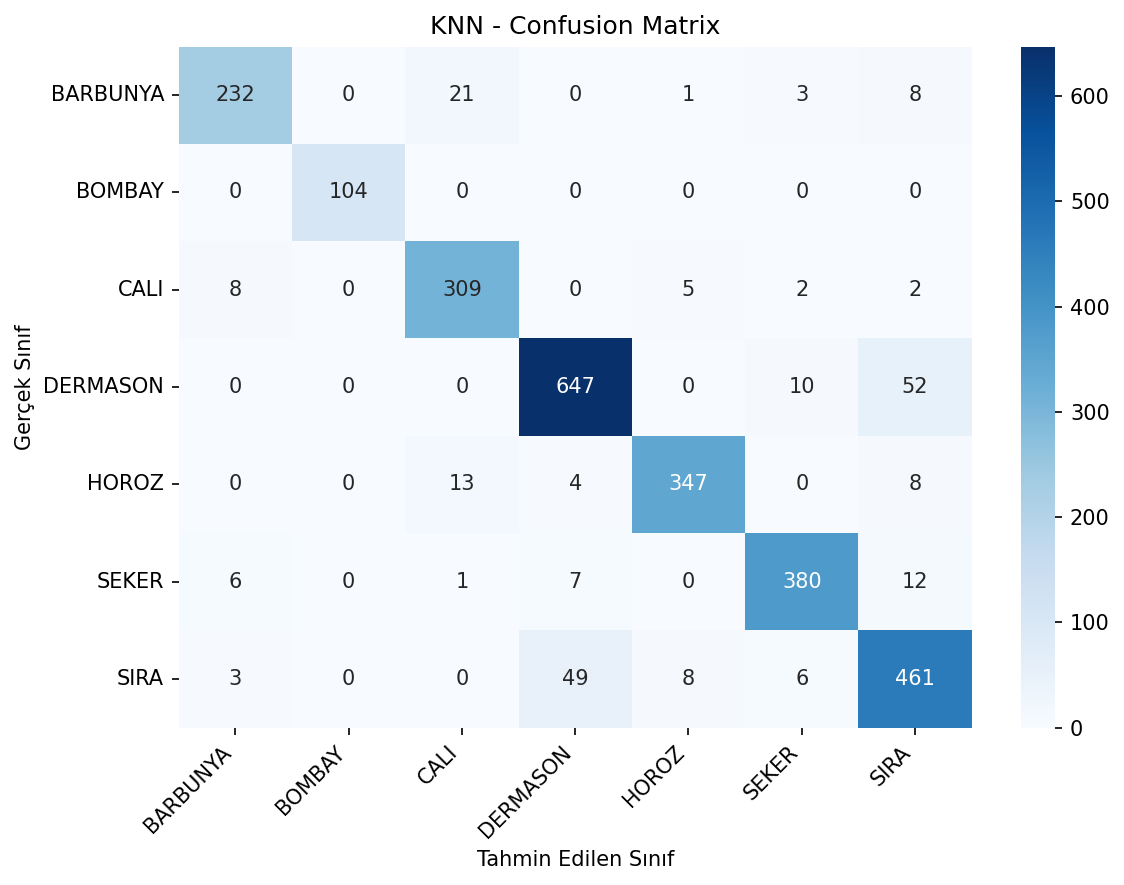

In [4]:
cm = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=plt.cm.Blues,
    xticklabels=knn.classes_,
    yticklabels=knn.classes_,
    ax=ax
)
plt.title("KNN - Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(path / "reports" / "figures" / "kisi1_knn_confusion_matrix.png", dpi=300, bbox_inches="tight") # Dosyada istenen isim
plt.show()
plt.close(fig)


Karar Ağacı(Decision Tree)

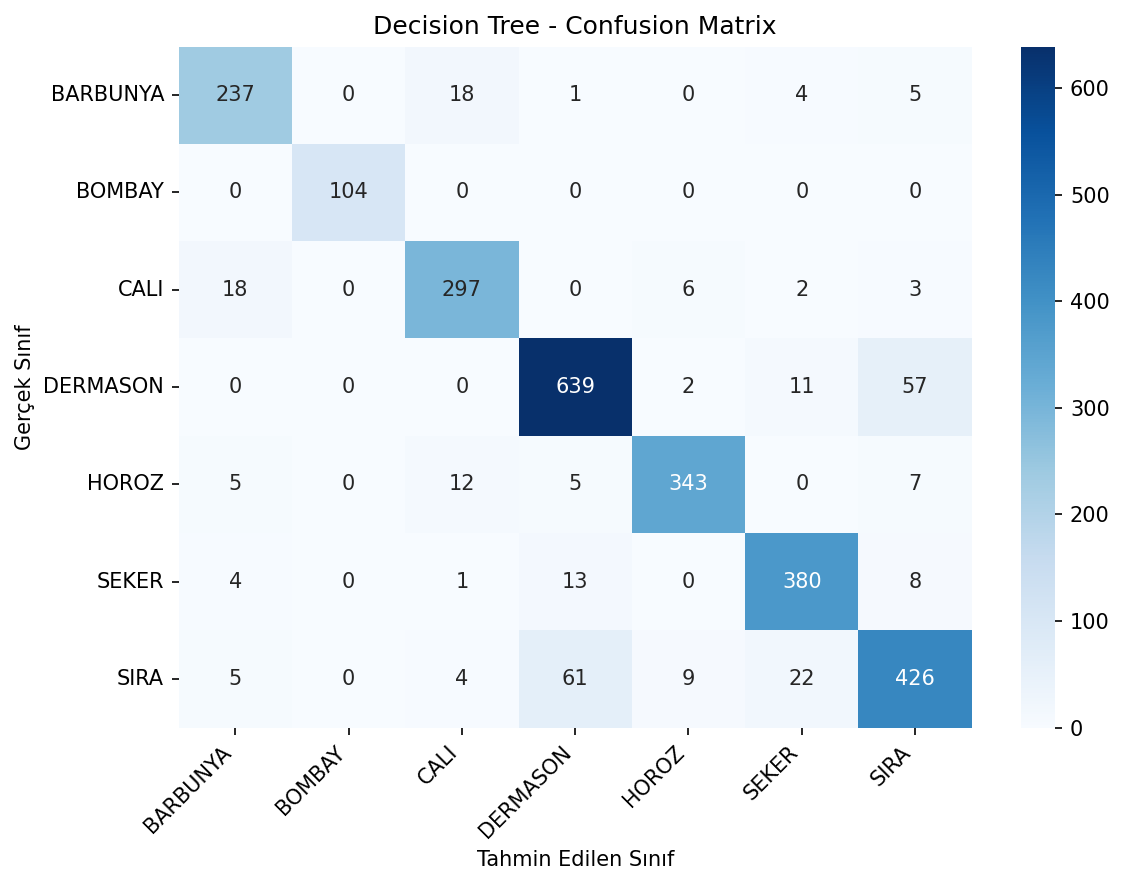

In [5]:
from sklearn.tree import DecisionTreeClassifier

# 1. Modeli tanımla
dt = DecisionTreeClassifier(random_state=42)

# 2. Modeli HAM VERİ ile eğit
dt.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_dt = dt.predict(X_test)

# 4. Metrikleri hesapla ve listeye ekle
precision_dt, recall_dt, f1_dt, _ = precision_recall_fscore_support(y_test, y_pred_dt, average='weighted')

model_results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Weighted Precision': precision_dt,
    'Weighted Recall': recall_dt,
    'Weighted F1-score': f1_dt
})

# 5. Grafiği (Confusion Matrix) çiz ve kaydet
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap=plt.cm.Blues,
    xticklabels=dt.classes_,
    yticklabels=dt.classes_,
    ax=ax
)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(path / "reports" / "figures" / "kisi1_decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [6]:
# Sonuçları gör
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8955334071613141

Sınıflandırma Raporu:
               precision    recall  f1-score   support

    BARBUNYA       0.88      0.89      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.89      0.91      0.90       326
    DERMASON       0.89      0.90      0.89       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.92       406
        SIRA       0.84      0.81      0.82       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



Gaussian Naive Bayes

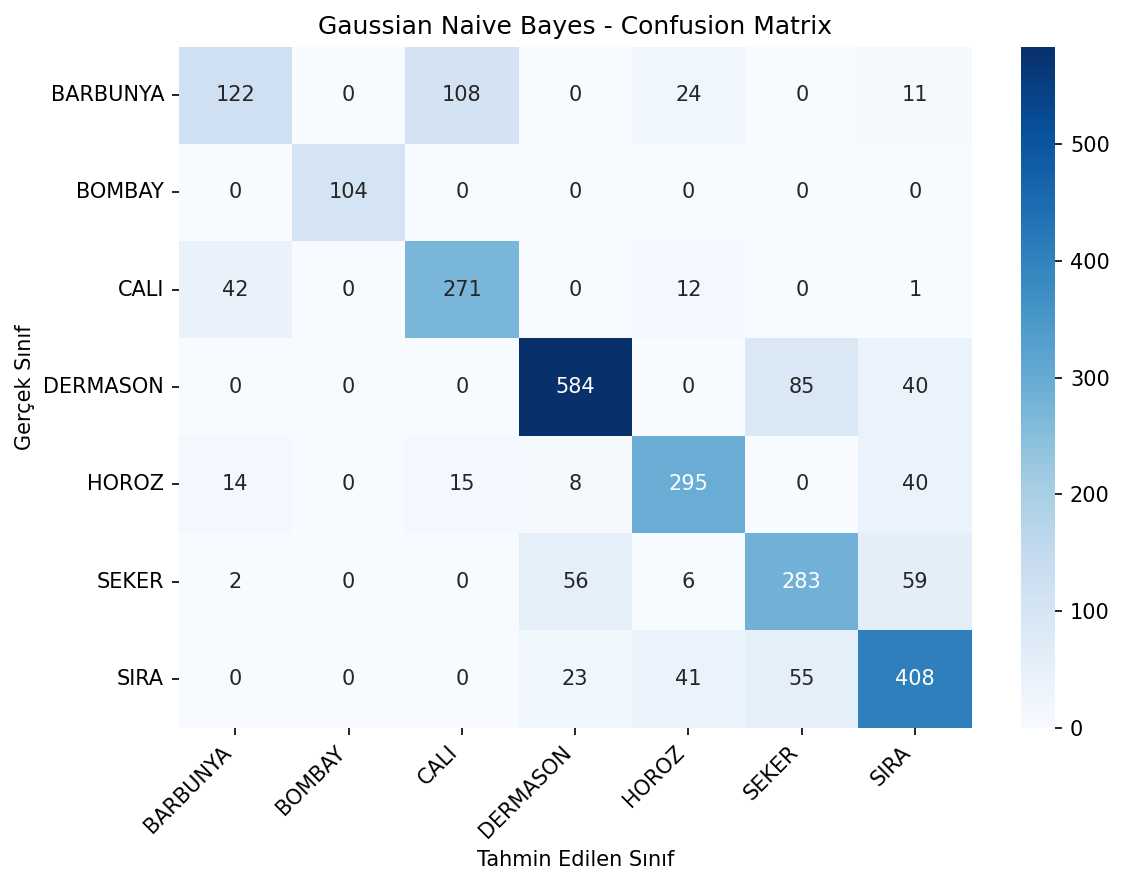

In [7]:
from sklearn.naive_bayes import GaussianNB

# 1. Modeli tanımla
gnb = GaussianNB()

# 2. Modeli HAM VERİ ile eğit
gnb.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_gnb = gnb.predict(X_test)

# 4. Metrikleri hesapla ve listeye ekle
precision_gnb, recall_gnb, f1_gnb, _ = precision_recall_fscore_support(y_test, y_pred_gnb, average='weighted')

model_results.append({
    'Model': 'Gaussian Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_gnb),
    'Weighted Precision': precision_gnb,
    'Weighted Recall': recall_gnb,
    'Weighted F1-score': f1_gnb
})

# 5. Grafiği çiz ve kaydet
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap=plt.cm.Blues,
    xticklabels=gnb.classes_,
    yticklabels=gnb.classes_,
    ax=ax
)
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(path / "reports" / "figures" / "kisi1_gaussian_nb_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [8]:
# Sonuçları gör
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_gnb))

GaussianNB Accuracy: 0.7630121816168328

Sınıflandırma Raporu:
               precision    recall  f1-score   support

    BARBUNYA       0.68      0.46      0.55       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.69      0.83      0.75       326
    DERMASON       0.87      0.82      0.85       709
       HOROZ       0.78      0.79      0.79       372
       SEKER       0.67      0.70      0.68       406
        SIRA       0.73      0.77      0.75       527

    accuracy                           0.76      2709
   macro avg       0.77      0.77      0.77      2709
weighted avg       0.76      0.76      0.76      2709



In [9]:
# Listeyi tabloya (DataFrame) ?evir
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Weighted F1-score",
    ascending=False
).reset_index(drop=True)

# Sonu?lar? belirtilen klas?re kaydet
results_df.to_csv(path / "reports" / "results" / "kisi1_model_sonuclari.csv", index=False, encoding="utf-8-sig")
